# AI Clustering

> Concepts and demos

In [33]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Set plot style
sns.set_theme(style="darkgrid")

### What is Clustering?
Clustering is an **Unsupervised Machine Learning** technique. Unlike supervised learning (such as classification), we don't have labeled data (no "correct answers"). The algorithm's job is to discover hidden patterns and group similar data points together.

### Real-world Applications
* **Customer Segmentation:** Grouping buyers with similar purchasing habits. 🎯 
* **Anomaly Detection:** Finding outliers (e.g., credit card fraud). 🚨 
* **Biology:** Grouping genes with similar expression patterns. 🧬 

### How K-Means Works (The Intuition)
1. Pick $K$ random points as the initial "centers" (centroids) of our clusters.
2. Assign every data point to its closest centroid. But how do we measure "closest"? We usually use the **Euclidean Distance**.

##### The Math: Euclidean Distance
Euclidean Distance is just the **Pythagorean Theorem** ($a^2 + b^2 = c^2$) applied to coordinates! To find the straight-line distance ($d$) between a data point $(x_1, y_1)$ and a centroid $(x_2, y_2)$, the algorithm calculates:

$$ d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} $$

<img src="https://mathcracker.com/images/legacy/distance-formula-1.jpg" width="400" alt="Euclidean Distance Graph">

3. Recalculate the center of each cluster based on the points assigned to it.
4. Repeat steps 2 and 3 until the centroids stop moving!

Raw Data coordinates (First 5 points):
x: -9.1139, y: 6.8136
x: -9.3546, y: 7.0928
x: -2.0157, y: 8.2818
x: -7.0102, y: -6.2208
x: -10.0612, y: 6.7187
----------------------------------------


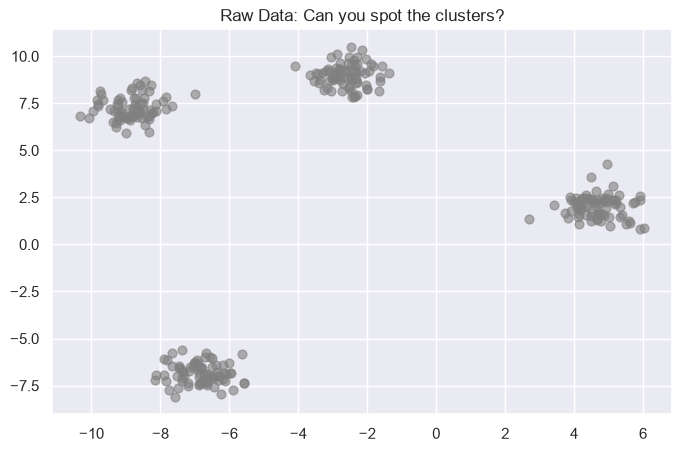

In [34]:
# 1. Generating synthetic 2D data for our basic example
# We create 300 points distributed around 4 centers
points, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

print("Raw Data coordinates (First 5 points):")
for p in points[:5]:
    print(f"x: {p[0]:.4f}, y: {p[1]:.4f}")
print("-" * 40)

# Let's plot the raw data (as the algorithm sees it: no colors, no labels)
plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1], s=40, color='gray', alpha=0.6)
plt.title("Raw Data: Can you spot the clusters?")
plt.show()

### Let's Apply K-Means!
Now, let's unleash the algorithm to find these 4 clusters automatically.

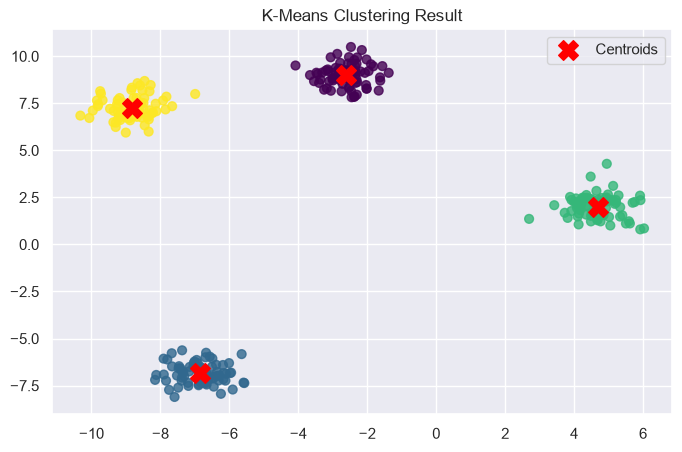

In [35]:
# 2. Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(points)

# 3. Get the predicted clusters and the centroids
predicted_clusters = kmeans.predict(points)
centroids = kmeans.cluster_centers_

# 4. Visualize the result
plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1], c=predicted_clusters, s=40, cmap='viridis', alpha=0.8)

# Plotting the centroids as red 'X's
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering Result")
plt.legend()
plt.show()

---
## Part 2: Under the Hood of Modern AI 🧠

If clustering groups points based on math and distance, how can we group **texts**, **images**, or **concepts**? Algorithms don't understand words; they only understand numbers.

### Enter: Embeddings
An Embedding is a translation. A Neural Network reads a sentence and translates its *semantic meaning* into a dense vector (a long list of numbers). 
* Sentences with similar meanings get vectors that are close to each other in this multidimensional space.

Let's see this in action using a real AI model!

In [36]:
from sentence_transformers import SentenceTransformer

# Load a lightweight, pre-trained AI model to generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

# Let's create a dataset of sentences from 3 different topics
sentences = [
    "A good pasta recipe needs fresh tomatoes and basil.",                     # Food
    "The soccer player scored a beautiful goal in the championship match.",    # Sports
    "Python is a great programming language for data analysis.",               # Tech
    "Tennis players need excellent hand-eye coordination.",                    # Sports
    "Baking chocolate chip cookies makes the house smell great.",              # Food
    "Machine learning algorithms are evolving fast every year.",               # Tech
    "The Olympics showcase the best athletes from around the world.",          # Sports
    "Sushi is a traditional Japanese dish with rice and raw fish.",            # Food
    "Software engineers write code to build web applications.",                # Tech
    "Basketball requires a lot of stamina, vertical jump, and teamwork.",      # Sports
    "I love eating pepperoni pizza with extra cheese on weekends.",            # Food
    "Cloud computing allows companies to scale their servers dynamically.",    # Tech
    "A heavy deadlift builds incredible strength in the lower back.",          # Sports
    "Deep learning models require powerful GPUs to train efficiently.",        # Tech
    "Grilling a perfect steak requires high heat and a little bit of butter."  # Food
]

# The AI translates sentences into mathematical coordinates (Embeddings)
embeddings = model.encode(sentences, device='cpu')

print(f"Number of sentences: {len(sentences)}")
print(f"Dimensions of each embedding vector: {embeddings.shape[1]}")
print(f"Preview of the first 5 numbers of the first sentence: \n{embeddings[0][:5]}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2953.65it/s]


Number of sentences: 15
Dimensions of each embedding vector: 384
Preview of the first 5 numbers of the first sentence: 
[-0.1464932  -0.03660886  0.009311    0.05287971 -0.04984839]


### Semantic Clustering
Now we have 384-dimensional vectors! We can use the exact same K-Means algorithm we learned in Part 1 to group these sentences by their *meaning*.

In [37]:
# Apply K-Means to our 384-dimensional text embeddings
kmeans_nlp = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_nlp.fit(embeddings)

# Print the results grouped by their cluster
clusters = {0: [], 1: [], 2: []}
for sentence, cluster_id in zip(sentences, kmeans_nlp.labels_):
    clusters[cluster_id].append(sentence)

print("Semantic Grouping Results:\n")
for cluster_id, cluster_sentences in clusters.items():
    print(f"Cluster {cluster_id}:")
    for s in cluster_sentences:
        print(f" - {s}")
    print()

Semantic Grouping Results:

Cluster 0:
 - Python is a great programming language for data analysis.
 - Machine learning algorithms are evolving fast every year.
 - Software engineers write code to build web applications.
 - Cloud computing allows companies to scale their servers dynamically.
 - Deep learning models require powerful GPUs to train efficiently.

Cluster 1:
 - The soccer player scored a beautiful goal in the championship match.
 - Tennis players need excellent hand-eye coordination.
 - The Olympics showcase the best athletes from around the world.
 - Basketball requires a lot of stamina, vertical jump, and teamwork.
 - A heavy deadlift builds incredible strength in the lower back.

Cluster 2:
 - A good pasta recipe needs fresh tomatoes and basil.
 - Baking chocolate chip cookies makes the house smell great.
 - Sushi is a traditional Japanese dish with rice and raw fish.
 - I love eating pepperoni pizza with extra cheese on weekends.
 - Grilling a perfect steak requires hig

### Visualizing High Dimensions (PCA)
We humans can only see in 2D or 3D, but our embeddings live in a 384-dimensional space. To visualize our semantic clusters, we use a technique called **PCA (Principal Component Analysis)** to squash the 384 dimensions down to just 2, preserving as much information as possible.

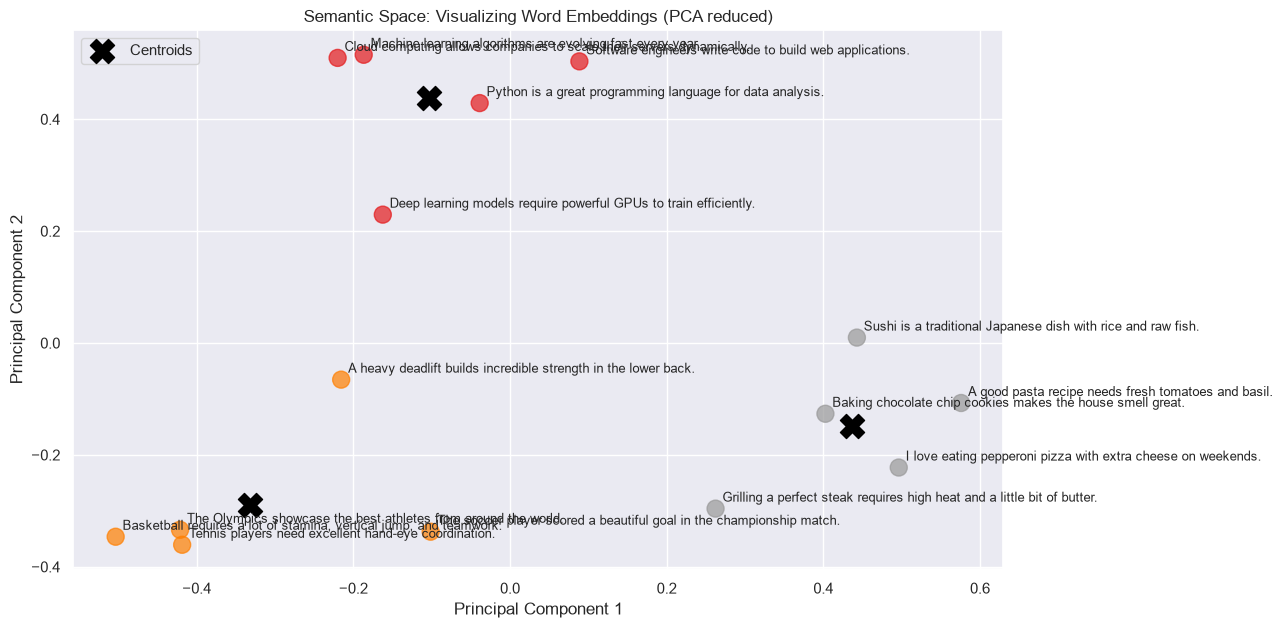

In [42]:
from sklearn.decomposition import PCA

# Reduce 384 dimensions down to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Transform the 384-dimensional centroids into 2D using the same PCA
reduced_centroids = pca.transform(kmeans_nlp.cluster_centers_)

# Plot the semantic clusters
plt.figure(figsize=(12, 7))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], 
                      c=kmeans_nlp.labels_, cmap='Set1', s=150, alpha=0.7)

# Plot the centroids on top
plt.scatter(reduced_centroids[:, 0], reduced_centroids[:, 1], 
            c='black', s=300, marker='X', label='Centroids')

# Add the actual sentences as labels to the points
for i, sentence in enumerate(sentences):
    plt.annotate(sentence, 
                 (reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title("Semantic Space: Visualizing Word Embeddings (PCA reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

### The Big Picture: Vector Databases 🚀
Why does this matter today?

When you ask ChatGPT a question over your company's documents, or when Spotify recommends a song, they are using **Vector Databases** (like Pinecone, Milvus, or ChromaDB). 

These databases don't search by keywords. They convert your search into an **Embedding**, and then use advanced clustering techniques (like *Inverted File Index*) to instantly find the "cluster" of documents that are mathematically closest to your question.

**Clustering is no longer just for data analysis; it's the engine powering modern AI retrieval!**